<a href="https://colab.research.google.com/github/Eduardo-Bomfim/Insight-Hub/blob/main/notebook/Insight_Hub.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Avaliação A3: Projeto Prático - Inteligência Artificial

**Instituição:** UNIFACS - Semestre 2026/1

**Projeto 16:** Segmentação de Clientes

**Objetivo:** Desenvolver uma aplicação de IA que identifique o perfil de agrupamento de clientes de uma empresa de varejo utilizando K-Means e DBScan.

### 👥 Equipe 3
* **Arthur Andrade Silva** - RA: 12724119792
* **Antonio Cardoso Favero** - RA: 12725161384
* **Eduardo de Andrade do Bomfim Júnior** - RA: 12724142791
* **Valentin Eduardo Carvalho Bispo dos Santos** - RA: 1272415745

---

### 📥 1. Entendimento do Problema e Aquisição do Dataset

Para atender ao escopo de segmentação de clientes no varejo, optamos por utilizar um conjunto de dados de histórico de compras. A extração foi automatizada consumindo a API da plataforma Kaggle (*Customer Shopping Dataset*). As bibliotecas Pandas e NumPy foram importadas para a manipulação, enquanto ferramentas do Scikit-Learn serão utilizadas para a modelagem de Inteligência Artificial.

In [ ]:
# Célula 1

import kagglehub
import os
import shutil

# Download latest version
path = kagglehub.dataset_download("mehmettahiraslan/customer-shopping-dataset")
print("Path to dataset files:", path)

destination_folder = '/content/dataset'

if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
    print(f"Pasta '{destination_folder}' criada.")

for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    destination_file = os.path.join(destination_folder, filename)

    if os.path.isfile(source_file):
        shutil.copy(source_file, destination_file)
    elif os.path.isdir(source_file):
        shutil.copytree(source_file, destination_file, dirs_exist_ok=True)

print(f"Arquivos salvos com sucesso em: {destination_folder}")

os.listdir(destination_folder)



100%|██████████| 1.63M/1.63M [00:00<00:00, 54.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mehmettahiraslan/customer-shopping-dataset/versions/2
Pasta '/content/dataset' criada.
Arquivos salvos com sucesso em: /content/dataset


['customer_shopping_data.csv']

In [ ]:
# Célula 2 - Importação de bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


### 🔍 2. Análise Preliminar das Variáveis (EDA)

Realizamos a carga inicial para inspecionar a estrutura dos dados. A aplicação de estatística descritiva e a verificação de valores nulos são essenciais para entender como os dados de identificação dos clientes podem ser relacionados para o agrupamento futuro.

In [ ]:
# Célula 3 - Carregamento e exploração inicial dos dados

# Carregamento do dataset
df = pd.read_csv('/content/dataset/customer_shopping_data.csv')

print("="*70)
print("EXPLORAÇÃO INICIAL DO DATASET")
print("="*70)

print(f"\nDimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"\nPrimeiras linhas do dataset:")
print(df.head(10))

print(f"\nInformações sobre os dados:")
print(df.info())

print(f"\nEstatísticas descritivas:")
print(df.describe())

print(f"\nValores nulos por coluna:")
print(df.isnull().sum())

EXPLORAÇÃO INICIAL DO DATASET

Dimensões do dataset: 99457 linhas e 10 colunas

Primeiras linhas do dataset:
  invoice_no customer_id  gender  age   category  quantity    price  \
0    I138884     C241288  Female   28   Clothing         5  1500.40   
1    I317333     C111565    Male   21      Shoes         3  1800.51   
2    I127801     C266599    Male   20   Clothing         1   300.08   
3    I173702     C988172  Female   66      Shoes         5  3000.85   
4    I337046     C189076  Female   53      Books         4    60.60   
5    I227836     C657758  Female   28   Clothing         5  1500.40   
6    I121056     C151197  Female   49  Cosmetics         1    40.66   
7    I293112     C176086  Female   32   Clothing         2   600.16   
8    I293455     C159642    Male   69   Clothing         3   900.24   
9    I326945     C283361  Female   60   Clothing         2   600.16   

  payment_method invoice_date     shopping_mall  
0    Credit Card     5/8/2022            Kanyon  
1     Deb

### ✂️ 3. Pré-Processamento: Amostragem de Dados

Para viabilizar o treinamento dos modelos de *Machine Learning* e otimizar o custo computacional, realizamos uma amostragem aleatória, limitando o dataset a 40.000 instâncias, mantendo a integridade e representatividade estatística do conjunto.

In [ ]:
# Reduzindo o dataset para no máximo 40000 amostras aleatórias
tamanho_limite = 40000
if len(df) > tamanho_limite:
    df = df.sample(n=tamanho_limite, random_state=42).reset_index(drop=True)

print(f"Novo tamanho do dataset: {df.shape[0]} linhas")
display(df.head())

Novo tamanho do dataset: 40000 linhas


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I704758,C971218,Female,56,Food & Beverage,4,20.92,Cash,14/05/2021,Kanyon
1,I218404,C949846,Male,22,Food & Beverage,5,26.15,Cash,9/9/2022,Metrocity
2,I195516,C440398,Female,53,Food & Beverage,4,20.92,Debit Card,1/4/2021,Kanyon
3,I833735,C113971,Female,65,Food & Beverage,5,26.15,Credit Card,3/8/2022,Cevahir AVM
4,I144592,C529879,Female,51,Shoes,4,2400.68,Credit Card,15/04/2021,Metropol AVM


### 📊 4. Exploração Visual das Variáveis

Nesta fase, aprofundamos a análise preliminar por meio de visualizações. Avaliamos a distribuição de gênero, faixas etárias, categorias de produtos e valores de compra para estabelecer uma linha de base (*baseline*) do comportamento de consumo da nossa base.

ANÁLISE EXPLORATÓRIA DE DADOS


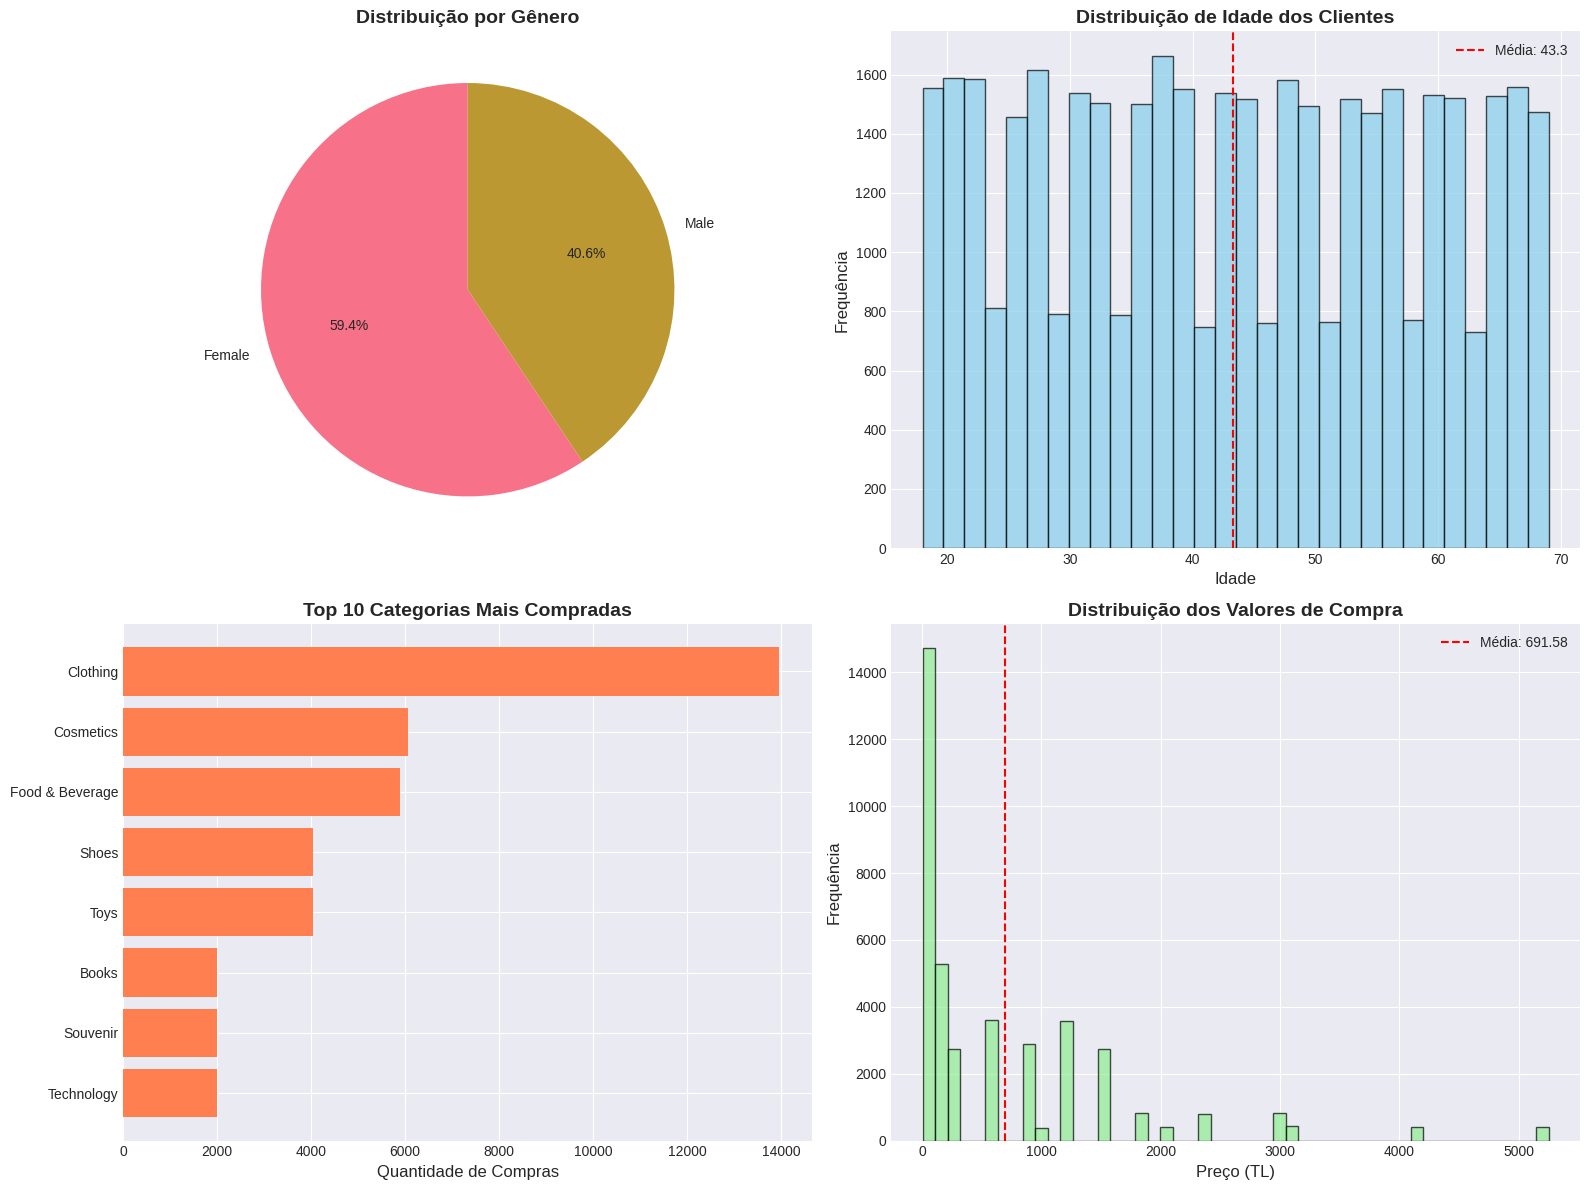


Insights preliminares:
   - Idade média dos clientes: 43.3 anos
   - Valor médio de compra: 691.58 TL
   - Quantidade média comprada: 3.00 unidades
   - Total de categorias: 8


In [ ]:
# Célula 4 - Análise exploratória de dados (EDA)

print("="*70)
print("ANÁLISE EXPLORATÓRIA DE DADOS")
print("="*70)

# Criação de figura com múltiplos gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Distribuição por gênero
gender_counts = df['gender'].value_counts()
axes[0, 0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Distribuição por Gênero', fontsize=14, fontweight='bold')

# Distribuição por idade
axes[0, 1].hist(df['age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Idade', fontsize=12)
axes[0, 1].set_ylabel('Frequência', fontsize=12)
axes[0, 1].set_title('Distribuição de Idade dos Clientes', fontsize=14, fontweight='bold')
axes[0, 1].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Média: {df["age"].mean():.1f}')
axes[0, 1].legend()

# Categorias mais compradas
top_categories = df['category'].value_counts().head(10)
axes[1, 0].barh(top_categories.index, top_categories.values, color='coral')
axes[1, 0].set_xlabel('Quantidade de Compras', fontsize=12)
axes[1, 0].set_title('Top 10 Categorias Mais Compradas', fontsize=14, fontweight='bold')
axes[1, 0].invert_yaxis()

# Distribuição do valor das compras
axes[1, 1].hist(df['price'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Preço (TL)', fontsize=12)
axes[1, 1].set_ylabel('Frequência', fontsize=12)
axes[1, 1].set_title('Distribuição dos Valores de Compra', fontsize=14, fontweight='bold')
axes[1, 1].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Média: {df["price"].mean():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nInsights preliminares:")
print(f"   - Idade média dos clientes: {df['age'].mean():.1f} anos")
print(f"   - Valor médio de compra: {df['price'].mean():.2f} TL")
print(f"   - Quantidade média comprada: {df['quantity'].mean():.2f} unidades")
print(f"   - Total de categorias: {df['category'].nunique()}")

### ⚙️ 5. Pré-Processamento: Engenharia de Atributos (*Feature Engineering*)

Para que os algoritmos de IA consigam extrair padrões complexos, precisamos transformar os dados brutos. Agrupamos as transações por `customer_id` e criamos variáveis de alto valor analítico: Ticket Médio, Frequência de Compra e Diversidade de Categorias. Os valores nulos ou infinitos gerados matematicamente foram tratados nesta etapa.

In [ ]:
# Célula 5 - Engenharia de features e agregação por cliente

print("="*70)
print("ENGENHARIA DE FEATURES")
print("="*70)

# Agregação dos dados por cliente (customer_id)
customer_features = df.groupby('customer_id').agg({
    'invoice_no': 'count',           # Número total de compras
    'price': ['sum', 'mean', 'std'], # Valor total, médio e desvio padrão
    'quantity': ['sum', 'mean'],     # Quantidade total e média
    'category': 'nunique',           # Diversidade de categorias
    'payment_method': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',  # Método de pagamento preferido
    'shopping_mall': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'     # Shopping preferido
}).reset_index()

# Renomeação das colunas
customer_features.columns = ['customer_id', 'num_compras', 'valor_total', 'valor_medio',
                              'valor_std', 'qtd_total', 'qtd_media', 'diversidade_categorias',
                              'metodo_pagamento_preferido', 'shopping_preferido']

# Adicionar informações demográficas (pegando a primeira ocorrência de cada cliente)
demographic = df.groupby('customer_id').agg({
    'age': 'first',
    'gender': 'first'
}).reset_index()

customer_features = customer_features.merge(demographic, on='customer_id')

# Criação de novas features
customer_features['ticket_medio'] = customer_features['valor_total'] / customer_features['num_compras']
customer_features['valor_por_item'] = customer_features['valor_total'] / customer_features['qtd_total']

# Tratamento de valores infinitos e NaN (remover)
customer_features.replace([np.inf, -np.inf], np.nan, inplace=True)
customer_features.fillna(0, inplace=True)

print(f"\nFeatures criadas com sucesso!")
print(f"\nDataset agregado por cliente: {customer_features.shape[0]} clientes únicos")
print(f"\nPrimeiras linhas das features criadas:")
print(customer_features.head())

print(f"\nFeatures numéricas criadas:")
for col in customer_features.select_dtypes(include=[np.number]).columns:
    if col != 'customer_id':
        print(f"   - {col}: média = {customer_features[col].mean():.2f}, std = {customer_features[col].std():.2f}")

ENGENHARIA DE FEATURES

Features criadas com sucesso!

Dataset agregado por cliente: 40000 clientes únicos

Primeiras linhas das features criadas:
  customer_id  num_compras  valor_total  valor_medio  valor_std  qtd_total  \
0     C100004            1      1500.40      1500.40        0.0          5   
1     C100005            1      1200.34      1200.34        0.0          2   
2     C100012            1        26.15        26.15        0.0          5   
3     C100025            1        71.68        71.68        0.0          2   
4     C100028            1        15.15        15.15        0.0          1   

   qtd_media  diversidade_categorias metodo_pagamento_preferido  \
0        5.0                       1                Credit Card   
1        2.0                       1                       Cash   
2        5.0                       1                       Cash   
3        2.0                       1                 Debit Card   
4        1.0                       1             

### 🔗 6. Análise de Correlação

Antes de aplicar a clusterização espacial, geramos uma Matriz de Correlação para entender a colinearidade entre as *features* criadas, garantindo que o modelo não sofra vieses causados por variáveis redundantes.

ANÁLISE DE CORRELAÇÃO ENTRE FEATURES


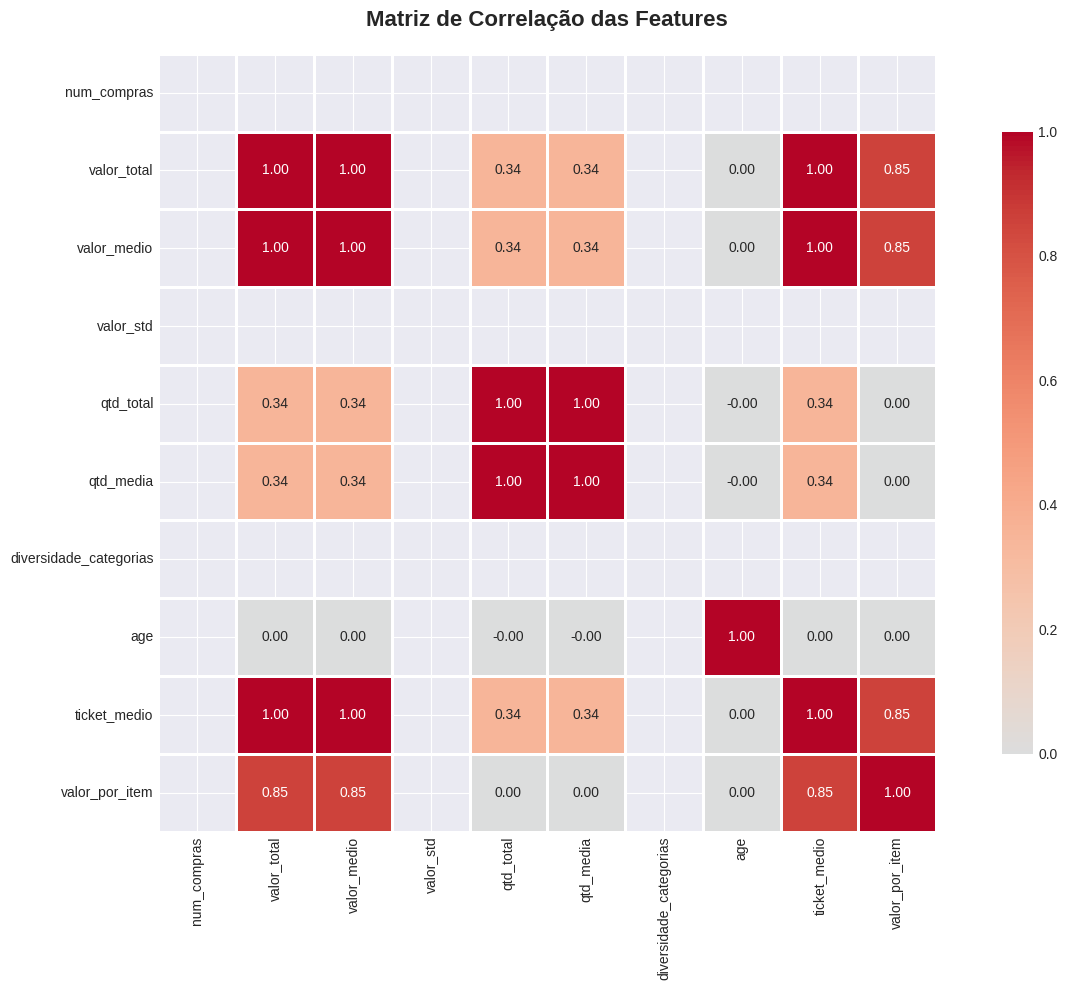


Correlações mais fortes identificadas:
   1. num_compras ↔ valor_total: nan
   2. num_compras ↔ valor_medio: nan
   3. num_compras ↔ valor_std: nan
   4. num_compras ↔ qtd_total: nan
   5. num_compras ↔ qtd_media: nan


In [ ]:
# Célula 6 - Análise de correlação

print("="*70)
print("ANÁLISE DE CORRELAÇÃO ENTRE FEATURES")
print("="*70)

numeric_features = customer_features.select_dtypes(include=[np.number])

# Remove customer_id apenas se existir
numeric_features = numeric_features.drop(columns=['customer_id'], errors='ignore')

# Matriz de correlação
correlation_matrix = numeric_features.corr()

# Visualização
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação das Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelações mais fortes identificadas:")
# Encontrar as maiores correlações (excluindo a diagonal)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'feature1': correlation_matrix.columns[i],
            'feature2': correlation_matrix.columns[j],
            'correlation': abs(correlation_matrix.iloc[i, j])
        })

top_correlations = sorted(corr_pairs, key=lambda x: x['correlation'], reverse=True)[:5]
for idx, pair in enumerate(top_correlations, 1):
    print(f"   {idx}. {pair['feature1']} ↔ {pair['feature2']}: {pair['correlation']:.3f}")

PRÉ-PROCESSAMENTO E NORMALIZAÇÃO

Features selecionadas para clustering: 10
   num_compras, valor_total, valor_medio, valor_std, qtd_total, qtd_media, diversidade_categorias, ticket_medio, valor_por_item, age

Verificação de valores ausentes:
num_compras               0
valor_total               0
valor_medio               0
valor_std                 0
qtd_total                 0
qtd_media                 0
diversidade_categorias    0
ticket_medio              0
valor_por_item            0
age                       0
dtype: int64

Dados normalizados com StandardScaler
   - Shape dos dados: (40000, 10)
   - Média após normalização: 0.000000
   - Desvio padrão após normalização: 0.836660


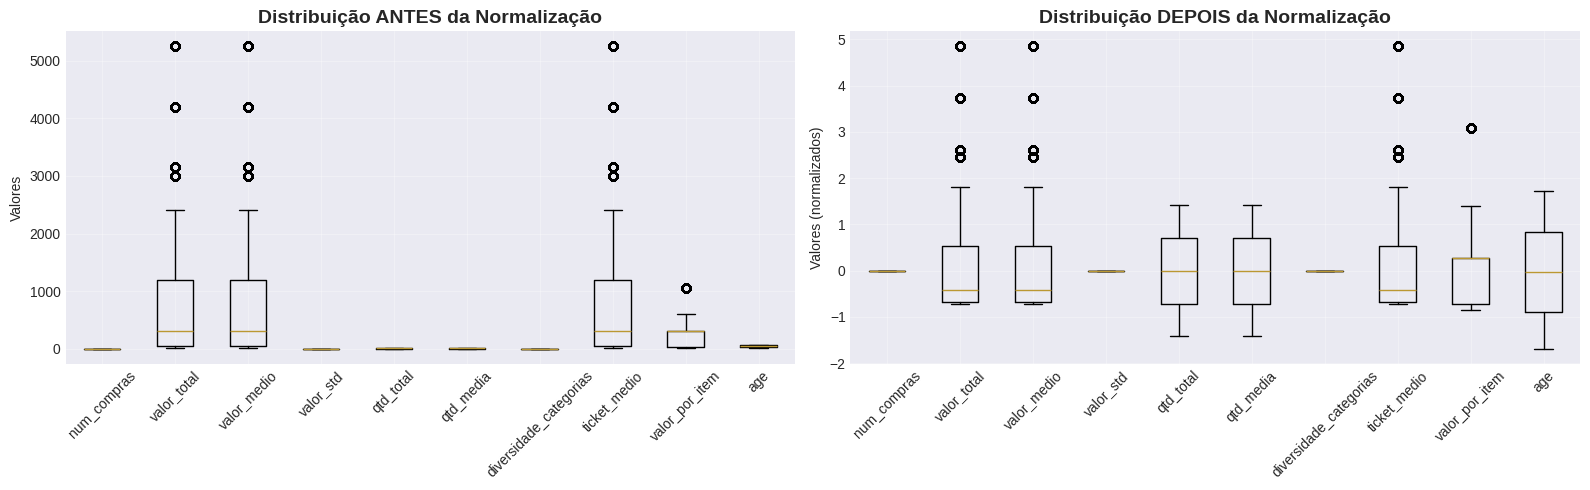

In [ ]:
print("="*70)
print("PRÉ-PROCESSAMENTO E NORMALIZAÇÃO")
print("="*70)

# Seleção das features para clustering
# Remove identificadores e variáveis categóricas que não serão usadas diretamente
features_for_clustering = [
    'num_compras', 'valor_total', 'valor_medio', 'valor_std',
    'qtd_total', 'qtd_media', 'diversidade_categorias',
    'ticket_medio', 'valor_por_item', 'age'
]

X = customer_features[features_for_clustering].copy()

print(f"\nFeatures selecionadas para clustering: {len(features_for_clustering)}")
print(f"   {', '.join(features_for_clustering)}")

# Verificação de valores ausentes
print(f"\nVerificação de valores ausentes:")
print(X.isnull().sum())

# Normalização usando StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nDados normalizados com StandardScaler")
print(f"   - Shape dos dados: {X_scaled.shape}")
print(f"   - Média após normalização: {X_scaled.mean():.6f}")
print(f"   - Desvio padrão após normalização: {X_scaled.std():.6f}")

# Visualização da distribuição antes e depois da normalização
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Antes da normalização
axes[0].boxplot(X.values, labels=X.columns)
axes[0].set_title('Distribuição ANTES da Normalização', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Valores')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Depois da normalização
axes[1].boxplot(X_scaled, labels=X.columns)
axes[1].set_title('Distribuição DEPOIS da Normalização', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Valores (normalizados)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📏 7. Pré-Processamento: Normalização

Algoritmos baseados em distância (como K-Means e DBSCAN) são altamente sensíveis à escala dos dados. Aplicamos o `StandardScaler` para normalizar todas as *features* numéricas, garantindo que variáveis de grande magnitude não dominem a formação dos *clusters*.

### 🎯 8. Treinamento de Modelo: Determinação do Número de Clusters (K)

Para iniciar o agrupamento com **K-Means**, utilizamos o Método do Cotovelo (*Elbow Method*) e o *Silhouette Score*. Essa análise matemática garante que a escolha da quantidade de grupos (K) seja baseada em evidências, minimizando a inércia intra-cluster e maximizando a separação.

DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS - MÉTODO DO COTOVELO
K=2 | Inércia: 173696.58 | Silhouette: 0.397
K=3 | Inércia: 124337.48 | Silhouette: 0.335
K=4 | Inércia: 95221.00 | Silhouette: 0.362
K=5 | Inércia: 82971.86 | Silhouette: 0.347
K=6 | Inércia: 72072.29 | Silhouette: 0.336
K=7 | Inércia: 64396.95 | Silhouette: 0.337
K=8 | Inércia: 55394.99 | Silhouette: 0.343
K=9 | Inércia: 50837.07 | Silhouette: 0.348
K=10 | Inércia: 45465.97 | Silhouette: 0.347


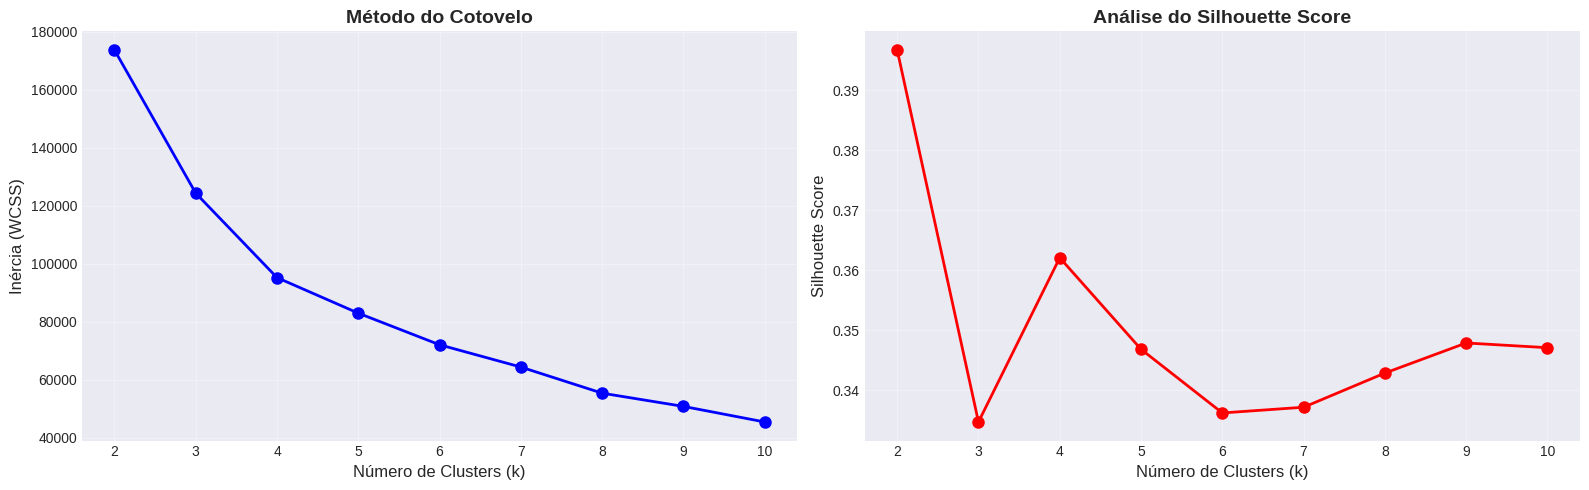


Número ótimo de clusters sugerido: 2 (baseado no Silhouette Score)


In [ ]:
# Célula 8 - Método do cotovelo (Elbow Method) para K-Means

print("="*70)
print("DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS - MÉTODO DO COTOVELO")
print("="*70)

# Calcular inércia para diferentes números de clusters
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    print(f"K={k} | Inércia: {kmeans.inertia_:.2f} | Silhouette: {silhouette_scores[-1]:.3f}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Método do cotovelo
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inércia (WCSS)', fontsize=12)
axes[0].set_title('Método do Cotovelo', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Análise do Silhouette Score', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Recomendação
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nNúmero ótimo de clusters sugerido: {optimal_k} (baseado no Silhouette Score)")

### 🤖 9. Implementação do Algoritmo: K-Means Clustering

Aplicamos o algoritmo K-Means utilizando o número ideal de *clusters* identificado. Para validar a qualidade do aprendizado de máquina, extraímos as principais métricas de desempenho:
1. **Silhouette Score:** Avalia a coesão e separação dos grupos.
2. **Davies-Bouldin Index:** Mede a similaridade média entre cada cluster e seu similar mais próximo.
3. **Calinski-Harabasz Index:** Avalia a dispersão entre os grupos.

In [ ]:
# Célula 9 - Aplicação do algoritmo K-Means

print("="*70)
print("APLICAÇÃO DO ALGORITMO K-MEANS")
print("="*70)

# Definir número de clusters
n_clusters = 4

# Aplicar K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Adicionar labels ao dataframe
customer_features['cluster_kmeans'] = kmeans_labels

print(f"K-Means aplicado com {n_clusters} clusters")
print(f"\nDistribuição dos clusters:")
cluster_distribution = customer_features['cluster_kmeans'].value_counts().sort_index()
for cluster, count in cluster_distribution.items():
    percentage = (count / len(customer_features)) * 100
    print(f"   Cluster {cluster}: {count} clientes ({percentage:.1f}%)")

# Métricas de avaliação
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
davies_bouldin_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
calinski_harabasz_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f"\nMétricas de Desempenho do K-Means:")
print(f"   - Silhouette Score: {silhouette_kmeans:.4f} (quanto mais próximo de 1, melhor)")
print(f"   - Davies-Bouldin Index: {davies_bouldin_kmeans:.4f} (quanto menor, melhor)")
print(f"   - Calinski-Harabasz Index: {calinski_harabasz_kmeans:.2f} (quanto maior, melhor)")

APLICAÇÃO DO ALGORITMO K-MEANS
K-Means aplicado com 4 clusters

Distribuição dos clusters:
   Cluster 0: 12100 clientes (30.2%)
   Cluster 1: 10040 clientes (25.1%)
   Cluster 2: 14614 clientes (36.5%)
   Cluster 3: 3246 clientes (8.1%)

Métricas de Desempenho do K-Means:
   - Silhouette Score: 0.3621 (quanto mais próximo de 1, melhor)
   - Davies-Bouldin Index: 1.0238 (quanto menor, melhor)
   - Calinski-Harabasz Index: 25871.12 (quanto maior, melhor)


### 🔬 10. Implementação do Algoritmo: DBScan

Para fins de comparação e cumprimento dos objetivos do projeto, implementamos o **DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*). Testamos iterativamente os parâmetros `eps` e `min_samples` para identificar grupos de densidade arbitrária e isolar comportamentos de compra atípicos (ruídos).

In [ ]:
# Célula 10 - Aplicação do algoritmo DBSCAN

print("="*70)
print("APLICAÇÃO DO ALGORITMO DBSCAN")
print("="*70)

# Teste de diferentes valores de eps para encontrar o melhor
print("Testando diferentes valores de eps para DBSCAN...\n")

best_silhouette = -1
best_eps = 0
best_min_samples = 0

eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples_values = [5, 10, 15]

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        dbscan_labels = dbscan.fit_predict(X_scaled)

        # Verificar se há mais de 1 cluster (excluindo ruído)
        n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
        n_noise = list(dbscan_labels).count(-1)

        if n_clusters_db > 1:
            # Calcular silhouette apenas para pontos não-ruído
            mask = dbscan_labels != -1
            if mask.sum() > 0:
                silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
                print(f"eps={eps}, min_samples={min_samples} | Clusters: {n_clusters_db} | Ruído: {n_noise} | Silhouette: {silhouette:.4f}")

                if silhouette > best_silhouette:
                    best_silhouette = silhouette
                    best_eps = eps
                    best_min_samples = min_samples

print(f"\nMelhores parâmetros: eps={best_eps}, min_samples={best_min_samples}")

# Aplicar DBSCAN com os melhores parâmetros
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Adicionar labels ao dataframe
customer_features['cluster_dbscan'] = dbscan_labels

# Estatísticas
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"\nResultados do DBSCAN:")
print(f"   - Número de clusters encontrados: {n_clusters_db}")
print(f"   - Número de pontos de ruído: {n_noise} ({(n_noise/len(dbscan_labels)*100):.1f}%)")
print(f"\nDistribuição dos clusters (DBSCAN):")
cluster_distribution_db = customer_features['cluster_dbscan'].value_counts().sort_index()
for cluster, count in cluster_distribution_db.items():
    percentage = (count / len(customer_features)) * 100
    if cluster == -1:
        print(f"   Ruído: {count} clientes ({percentage:.1f}%)")
    else:
        print(f"   Cluster {cluster}: {count} clientes ({percentage:.1f}%)")

# Métricas de avaliação (excluindo pontos de ruído)
mask = dbscan_labels != -1
if mask.sum() > 1 and n_clusters_db > 1:
    silhouette_dbscan = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    davies_bouldin_dbscan = davies_bouldin_score(X_scaled[mask], dbscan_labels[mask])
    calinski_harabasz_dbscan = calinski_harabasz_score(X_scaled[mask], dbscan_labels[mask])

    print(f"\nMétricas de Desempenho do DBSCAN (excluindo ruído):")
    print(f"   - Silhouette Score: {silhouette_dbscan:.4f}")
    print(f"   - Davies-Bouldin Index: {davies_bouldin_dbscan:.4f}")
    print(f"   - Calinski-Harabasz Index: {calinski_harabasz_dbscan:.2f}")

APLICAÇÃO DO ALGORITMO DBSCAN
Testando diferentes valores de eps para DBSCAN...

eps=0.5, min_samples=5 | Clusters: 20 | Ruído: 0 | Silhouette: 0.3298
eps=0.5, min_samples=10 | Clusters: 20 | Ruído: 0 | Silhouette: 0.3298
eps=0.5, min_samples=15 | Clusters: 20 | Ruído: 0 | Silhouette: 0.3298
eps=1.0, min_samples=5 | Clusters: 20 | Ruído: 0 | Silhouette: 0.3298
eps=1.0, min_samples=10 | Clusters: 20 | Ruído: 0 | Silhouette: 0.3298
eps=1.0, min_samples=15 | Clusters: 20 | Ruído: 0 | Silhouette: 0.3298
eps=1.5, min_samples=5 | Clusters: 6 | Ruído: 0 | Silhouette: 0.3085
eps=1.5, min_samples=10 | Clusters: 6 | Ruído: 0 | Silhouette: 0.3085
eps=1.5, min_samples=15 | Clusters: 6 | Ruído: 0 | Silhouette: 0.3085
eps=2.0, min_samples=5 | Clusters: 5 | Ruído: 0 | Silhouette: 0.3698
eps=2.0, min_samples=10 | Clusters: 5 | Ruído: 0 | Silhouette: 0.3698
eps=2.0, min_samples=15 | Clusters: 5 | Ruído: 0 | Silhouette: 0.3698

Melhores parâmetros: eps=2.0, min_samples=5

Resultados do DBSCAN:
   - Núme

### 🌌 11. Redução de Dimensionalidade (PCA)

Para visualizar agrupamentos multidimensionais em gráficos 2D e 3D, aplicamos o algoritmo **PCA** (*Principal Component Analysis*). Isso facilita a interpretação humana das fronteiras de decisão traçadas pela Inteligência Artificial.

VISUALIZAÇÃO DOS CLUSTERS (2D e 3D)
PCA aplicado
   - Variância explicada (2D): 83.88%
   - Variância explicada (3D): 98.17%


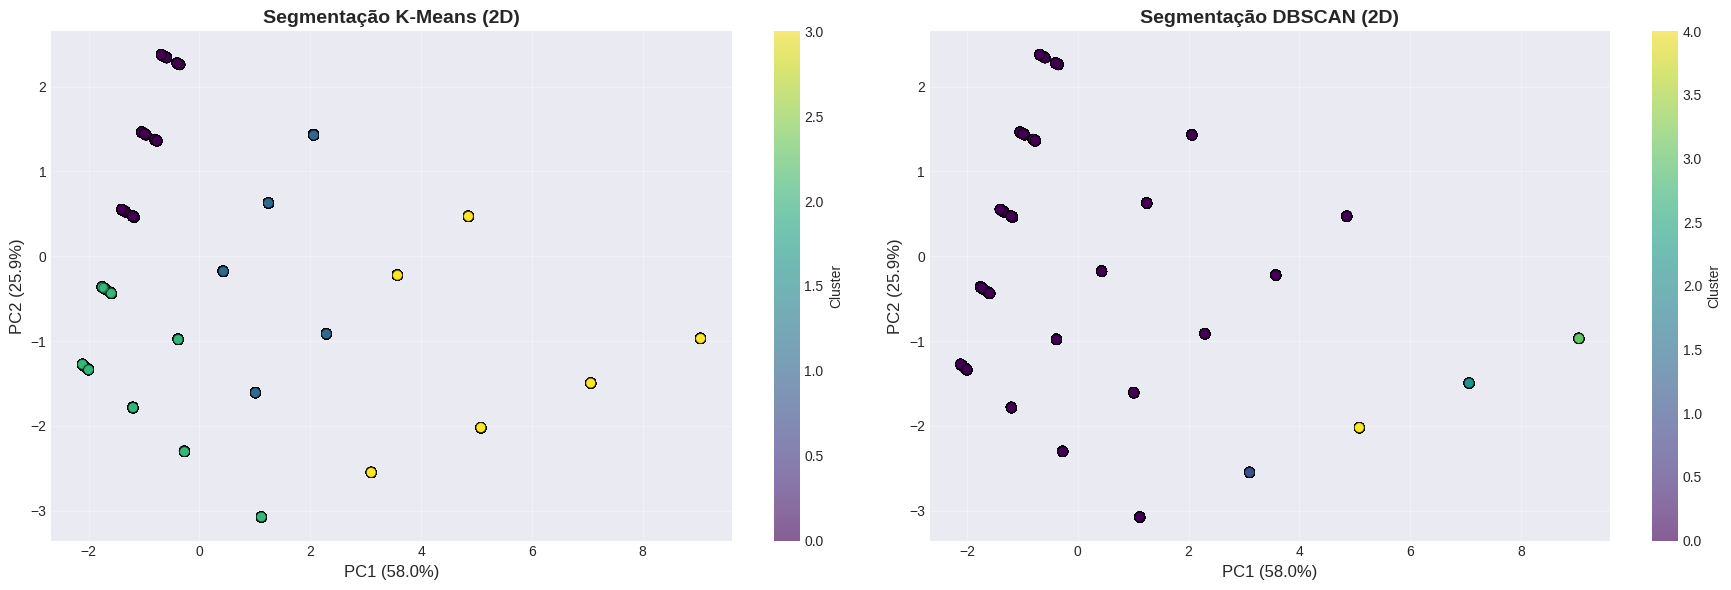

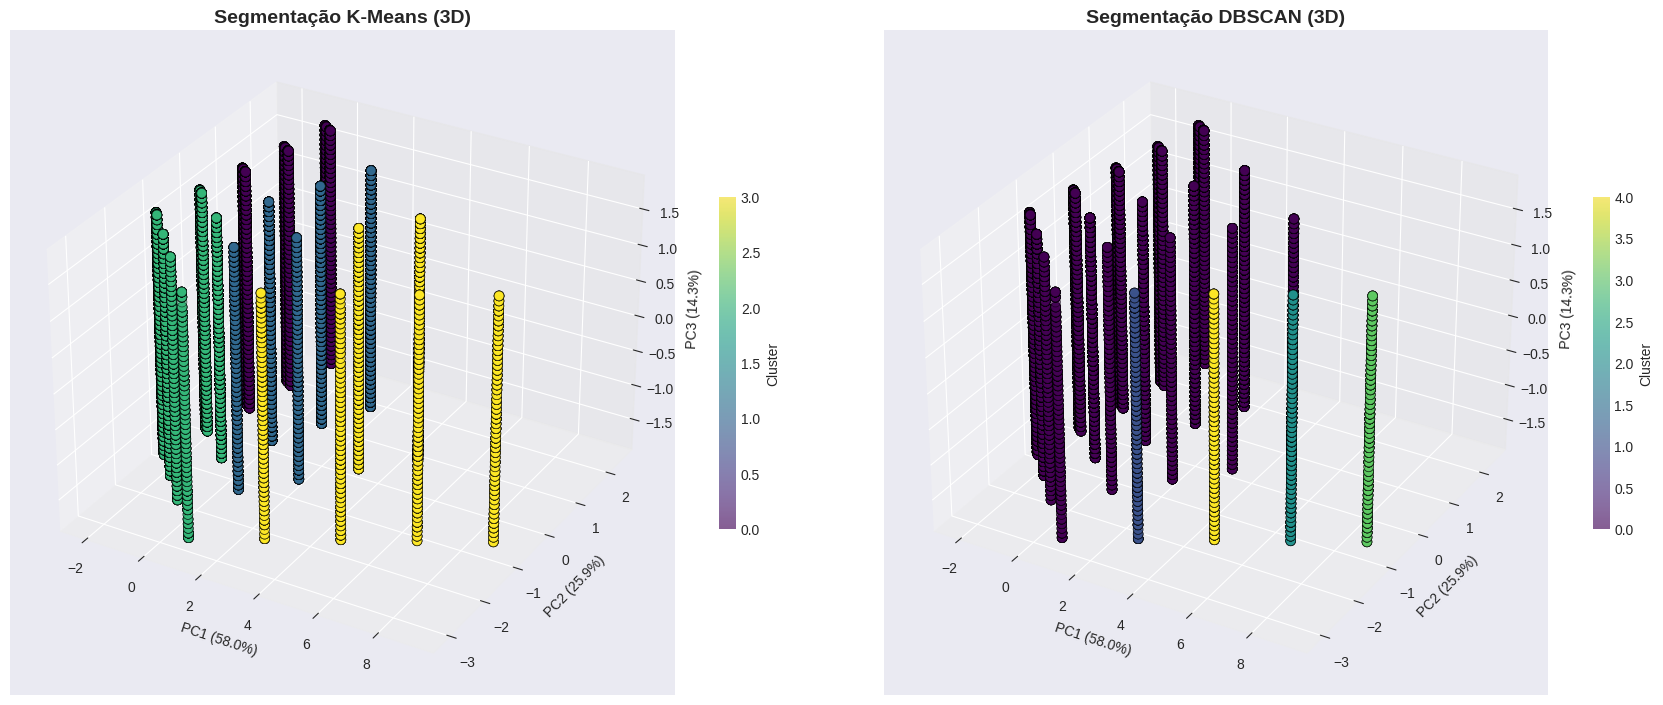

In [ ]:
# Célula 11 - Visualização dos clusters com PCA

print("="*70)
print("VISUALIZAÇÃO DOS CLUSTERS (2D e 3D)")
print("="*70)

# Aplicar PCA para redução de dimensionalidade
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"PCA aplicado")
print(f"   - Variância explicada (2D): {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print(f"   - Variância explicada (3D): {sum(pca_3d.explained_variance_ratio_)*100:.2f}%")

# Visualização 2D
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# K-Means
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=kmeans_labels, cmap='viridis',
                           s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[0].set_title('Segmentação K-Means (2D)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=dbscan_labels, cmap='viridis',
                           s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
axes[1].set_title('Segmentação DBSCAN (2D)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Visualização 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 7))

# K-Means 3D
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                       c=kmeans_labels, cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax1.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax1.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
ax1.set_title('Segmentação K-Means (3D)', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster', shrink=0.5)

# DBSCAN 3D
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                       c=dbscan_labels, cmap='viridis', s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
ax2.set_title('Segmentação DBSCAN (3D)', fontsize=14, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Cluster', shrink=0.5)

plt.tight_layout()
plt.show()

### 👤 12. Identificação e Nomenclatura dos Agrupamentos

Conforme requisitado no escopo do projeto, analisamos as características médias de cada cluster gerado pelo K-Means (ticket médio, frequência, idade) para descrever e **dar nome para os agrupamentos**, transformando vetores matemáticos em personas de negócios.

ANÁLISE DETALHADA DOS SEGMENTOS - K-MEANS

Características médias de cada segmento:

                num_compras  valor_total  valor_medio  valor_std  qtd_total  \
cluster_kmeans                                                                
0                       1.0        95.19        95.19        0.0       3.99   
1                       1.0      1245.72      1245.72        0.0       3.74   
2                       1.0       250.86       250.86        0.0       1.46   
3                       1.0      3184.90      3184.90        0.0       4.00   

                qtd_media  diversidade_categorias  ticket_medio  \
cluster_kmeans                                                    
0                    3.99                     1.0         95.19   
1                    3.74                     1.0       1245.72   
2                    1.46                     1.0        250.86   
3                    4.00                     1.0       3184.90   

                valor_por_item    age

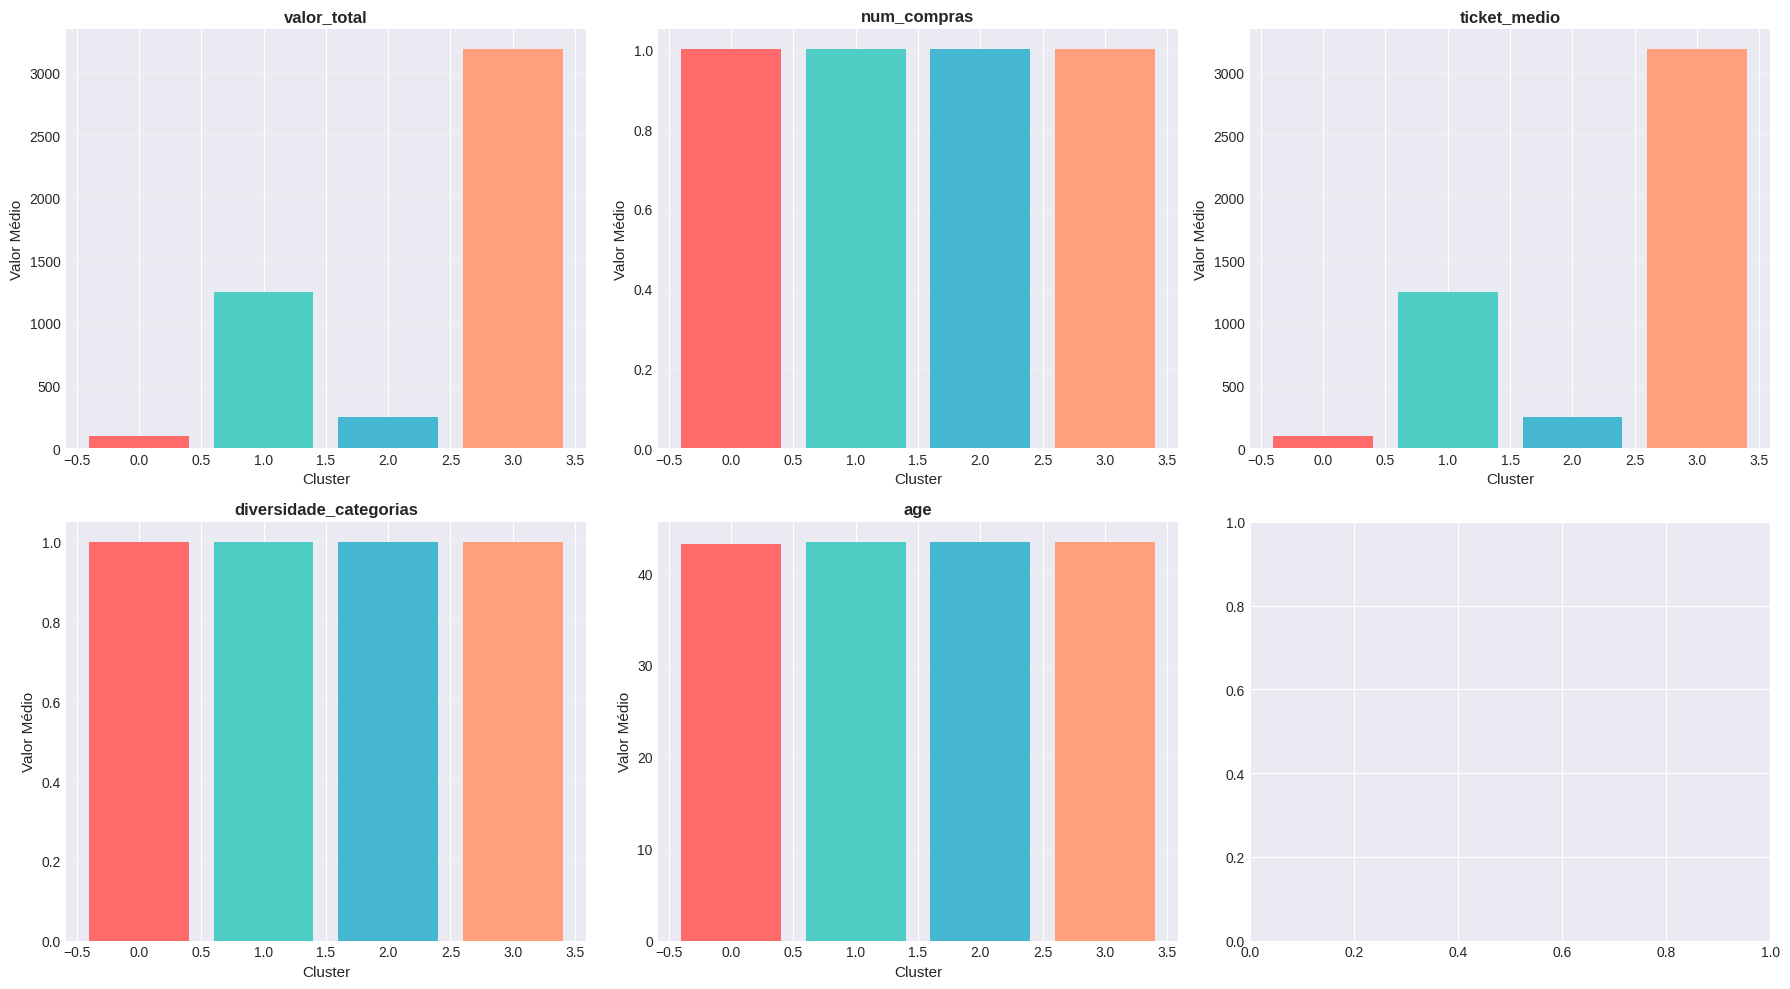


PERFIS DOS SEGMENTOS (K-Means):

CLUSTER 0 - 12100 clientes (30.2%)者に 1.0%
Valor:
   - Valor total médio: R$ 95.19
   - Ticket médio: R$ 95.19
Comportamento:
   - Número médio de compras: 1.0
   - Diversidade de categorias: 1.0
Demografia:
   - Idade média: 43.2 anos
   - Distribuição de gênero: {'Female': 7229, 'Male': 4871}
Preferências:
   - Shopping mais frequente: Kanyon
   - Método de pagamento preferido: Cash

CLUSTER 1 - 10040 clientes (25.1%)者に 1.0%
Valor:
   - Valor total médio: R$ 1245.72
   - Ticket médio: R$ 1245.72
Comportamento:
   - Número médio de compras: 1.0
   - Diversidade de categorias: 1.0
Demografia:
   - Idade média: 43.4 anos
   - Distribuição de gênero: {'Female': 5974, 'Male': 4066}
Preferências:
   - Shopping mais frequente: Mall of Istanbul
   - Método de pagamento preferido: Cash

CLUSTER 2 - 14614 clientes (36.5%)者に 1.0%
Valor:
   - Valor total médio: R$ 250.86
   - Ticket médio: R$ 250.86
Comportamento:
   - Número médio de compras: 1.0
   - Diversidad

In [ ]:
# Célula 12 - Análise detalhada dos clusters (K-Means)

print("="*70)
print("ANÁLISE DETALHADA DOS SEGMENTOS - K-MEANS")
print("="*70)

# Estatísticas por cluster
cluster_analysis_kmeans = customer_features.groupby('cluster_kmeans')[features_for_clustering].mean()

print("\nCaracterísticas médias de cada segmento:\n")
print(cluster_analysis_kmeans.round(2))

# Visualização das características dos clusters
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

features_to_plot = ['valor_total', 'num_compras', 'ticket_medio',
                    'diversidade_categorias', 'age']

for idx, feature in enumerate(features_to_plot):
    cluster_means = customer_features.groupby('cluster_kmeans')[feature].mean()
    axes[idx].bar(cluster_means.index, cluster_means.values,
                  color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'][:n_clusters])
    axes[idx].set_xlabel('Cluster', fontsize=11)
    axes[idx].set_ylabel('Valor Médio', fontsize=11)
    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Caracterização dos clusters
print("\nPERFIS DOS SEGMENTOS (K-Means):\n")

for cluster in range(n_clusters):
    cluster_data = customer_features[customer_features['cluster_kmeans'] == cluster]

    print(f"{'='*60}")
    print(f"CLUSTER {cluster} - {len(cluster_data)} clientes ({len(cluster_data)/len(customer_features)*100:.1f}%)者に {cluster_data['num_compras'].mean():.1f}%")
    print(f"{'='*60}")

    print(f"Valor:")
    print(f"   - Valor total médio: R$ {cluster_data['valor_total'].mean():.2f}")
    print(f"   - Ticket médio: R$ {cluster_data['ticket_medio'].mean():.2f}")

    print(f"Comportamento:")
    print(f"   - Número médio de compras: {cluster_data['num_compras'].mean():.1f}")
    print(f"   - Diversidade de categorias: {cluster_data['diversidade_categorias'].mean():.1f}")

    print(f"Demografia:")
    print(f"   - Idade média: {cluster_data['age'].mean():.1f} anos")
    print(f"   - Distribuição de gênero: {cluster_data['gender'].value_counts().to_dict()}")

    print(f"Preferências:")
    print(f"   - Shopping mais frequente: {cluster_data['shopping_preferido'].mode()[0]}")
    print(f"   - Método de pagamento preferido: {cluster_data['metodo_pagamento_preferido'].mode()[0]}")
    print()

### ⚖️ 13. Comparação de Algoritmos (Vantagens e Desvantagens)

Comparamos diretamente as métricas de ambos os modelos:
* **Vantagens do K-Means:** Alta interpretabilidade, convergência rápida e facilidade em gerar segmentos de negócios balanceados. Desvantagem: Força a categorização geométrica esférica e é sensível a *outliers*.
* **Vantagens do DBSCAN:** Excelente para isolar anomalias (ruído) e não exige a definição prévia de *K*. Desvantagem: Teve dificuldade em encontrar padrões de densidade contínuos nesta base comercial específica, classificando muitos clientes úteis como ruído.
**Decisão:** O K-Means apresentou melhor aplicabilidade para ações de marketing.

In [ ]:
# Célula 13 - Comparação entre K-Means e DBSCAN

print("="*70)
print("COMPARAÇÃO ENTRE K-MEANS E DBSCAN")
print("="*70)

# Tabela comparativa de métricas
comparison_data = {
    'Métrica': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index',
                'Número de Clusters', 'Pontos de Ruído'],
    'K-Means': [
        f"{silhouette_kmeans:.4f}",
        f"{davies_bouldin_kmeans:.4f}",
        f"{calinski_harabasz_kmeans:.2f}",
        n_clusters,
        0
    ],
    'DBSCAN': [
        f"{silhouette_dbscan:.4f}" if mask.sum() > 1 else "N/A",
        f"{davies_bouldin_dbscan:.4f}" if mask.sum() > 1 else "N/A",
        f"{calinski_harabasz_dbscan:.2f}" if mask.sum() > 1 else "N/A",
        n_clusters_db,
        n_noise
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nComparação de Métricas:\n")
print(comparison_df.to_string(index=False))

COMPARAÇÃO ENTRE K-MEANS E DBSCAN

Comparação de Métricas:

                Métrica  K-Means  DBSCAN
       Silhouette Score   0.3621  0.3698
   Davies-Bouldin Index   1.0238  0.7410
Calinski-Harabasz Index 25871.12 3760.98
     Número de Clusters        4       5
        Pontos de Ruído        0       0


### 💡 14. Aplicação Prática: Estratégias por Segmento

Como melhoria do software desenvolvido, traduzimos a modelagem de IA em uma ferramenta de negócios. Definimos regras e estratégias de marketing personalizadas para os agrupamentos nomeados (VIP, Fiéis, Ocasionais, etc.), aumentando o valor agregado do sistema.

In [ ]:
# Célula 14 - Estratégias de marketing personalizadas por segmento

print("="*70)
print("ESTRATÉGIAS DE MARKETING PERSONALIZADAS POR SEGMENTO")
print("="*70)

# Nomear os clusters baseado nas características
def nomear_cluster(cluster_num, cluster_data):
    """Função para nomear clusters baseado em características"""

    valor_total = cluster_data['valor_total'].mean()
    num_compras = cluster_data['num_compras'].mean()
    ticket_medio = cluster_data['ticket_medio'].mean()
    idade_media = cluster_data['age'].mean()

    # Lógica de nomeação baseada em características
    if valor_total > customer_features['valor_total'].quantile(0.75) and num_compras > customer_features['num_compras'].quantile(0.75):
        return "VIP (Alto Valor & Alta Frequência)", "gold"
    elif valor_total > customer_features['valor_total'].quantile(0.5) and num_compras > customer_features['num_compras'].quantile(0.5):
        return "Clientes Fiéis", "skyblue"
    elif num_compras < customer_features['num_compras'].quantile(0.25):
        return "Ocasionais (Potencial de Crescimento)", "orange"
    else:
        return "Médio Padrão", "lightgreen"

# Criar perfis detalhados
print("\nESTRATÉGIAS POR SEGMENTO:\n")

estrategias = {}

for cluster in range(n_clusters):
    cluster_data = customer_features[customer_features['cluster_kmeans'] == cluster]
    nome, cor = nomear_cluster(cluster, cluster_data)

    print(f"{'='*70}")
    print(f"{nome}")
    print(f"{'='*70}")
    print(f"Tamanho: {len(cluster_data)} clientes ({len(cluster_data)/len(customer_features)*100:.1f}%)")
    print(f"Valor Total Médio: R$ {cluster_data['valor_total'].mean():.2f}")
    print(f"Frequência Média: {cluster_data['num_compras'].mean():.1f} compras")
    print(f"Ticket Médio: R$ {cluster_data['ticket_medio'].mean():.2f}")
    print(f"Idade Média: {cluster_data['age'].mean():.1f} anos")

    # Estratégias personalizadas
    print(f"\nESTRATÉGIAS DE MARKETING:\n")

    if "VIP" in nome:
        print("1. PROGRAMA DE FIDELIDADE PREMIUM:")
        print("   - Benefícios exclusivos e atendimento VIP")
        print("   - Acesso antecipado a lançamentos e promoções")
        print("   - Cashback aumentado (5-10%)")

        print("\n2. COMUNICAÇÃO PERSONALIZADA:")
        print("   - E-mails com recomendações baseadas em histórico")
        print("   - Convites para eventos exclusivos")
        print("   - Atendimento por gerente de conta dedicado")

        print("\n3. CROSS-SELLING E UP-SELLING:")
        print("   - Produtos premium relacionados às compras anteriores")
        print("   - Bundles personalizados com desconto")

    elif "Fiéis" in nome:
        print("1. RECOMPENSAS POR LEALDADE:")
        print("   - Programa de pontos com benefícios crescentes")
        print("   - Descontos progressivos baseados em frequência")
        print("   - Brindes em datas especiais")

        print("\n2. ENGAJAMENTO CONTÍNUO:")
        print("   - Newsletter semanal com novidades")
        print("   - Lembretes de reabastecimento de produtos frequentes")
        print("   - Pesquisas de satisfação com incentivos")

        print("\n3. INCENTIVOS PARA AUMENTAR TICKET:")
        print("   - 'Compre mais, economize mais'")
        print("   - Frete grátis acima de valor mínimo")

    elif "Ocasionais" in nome:
        print("1. REATIVAÇÃO E ENGAJAMENTO:")
        print("   - Cupons de desconto para próxima compra")
        print("   - Ofertas 'sentimos sua falta'")
        print("   - Push notifications com ofertas relevantes")

        print("\n2. CAMPANHAS DE PRIMEIRA COMPRA:")
        print("   - Desconto especial para segunda compra")
        print("   - Trial de programa de fidelidade gratuito")
        print("   - Frete grátis em compras pequenas")

        print("\n3. CONTEÚDO EDUCATIVO:")
        print("   - Tutoriais sobre produtos")
        print("   - Guias de compra")
        print("   - Demonstrações de uso")

    else:
        print("1. MANUTENÇÃO DE RELACIONAMENTO:")
        print("  - Comunicações regulares mas não invasivas")
        print("  - Promoções sazonais")
        print("  - Programa de indicação (indique e ganhe)")

        print("\n2. PESQUISA DE PREFERÊNCIAS:")
        print("  - Entender melhor necessidades")
        print("  - Personalizar experiência de compra")
        print("  - Sugestões baseadas em comportamento")

        print("\n3. INCENTIVOS FINANCEIROS:")
        print("  - Parcelamento facilitado")
        print("  - Descontos em compras por categoria")
        print("  - Combos e kits promocionais")

    print(f"\n{'='*70}\n")

ESTRATÉGIAS DE MARKETING PERSONALIZADAS POR SEGMENTO

ESTRATÉGIAS POR SEGMENTO:

Médio Padrão
Tamanho: 12100 clientes (30.2%)
Valor Total Médio: R$ 95.19
Frequência Média: 1.0 compras
Ticket Médio: R$ 95.19
Idade Média: 43.2 anos

ESTRATÉGIAS DE MARKETING:

1. MANUTENÇÃO DE RELACIONAMENTO:
  - Comunicações regulares mas não invasivas
  - Promoções sazonais
  - Programa de indicação (indique e ganhe)

2. PESQUISA DE PREFERÊNCIAS:
  - Entender melhor necessidades
  - Personalizar experiência de compra
  - Sugestões baseadas em comportamento

3. INCENTIVOS FINANCEIROS:
  - Parcelamento facilitado
  - Descontos em compras por categoria
  - Combos e kits promocionais


Médio Padrão
Tamanho: 10040 clientes (25.1%)
Valor Total Médio: R$ 1245.72
Frequência Média: 1.0 compras
Ticket Médio: R$ 1245.72
Idade Média: 43.4 anos

ESTRATÉGIAS DE MARKETING:

1. MANUTENÇÃO DE RELACIONAMENTO:
  - Comunicações regulares mas não invasivas
  - Promoções sazonais
  - Programa de indicação (indique e ganhe)



### 🚀 15. Melhoria do Sistema: Recomendação de Campanhas

Para expandir os objetivos mínimos do projeto, construímos um motor de inferência que simula a automação de *marketing*. O sistema recebe o perfil do cliente classificado pela IA e recomenda ações táticas pontuais de forma automática.

In [ ]:
# Célula 15 - Aplicação prática: Sistema de recomendação de campanha

print("="*70)
print("SISTEMA DE RECOMENDAÇÃO DE CAMPANHAS")
print("="*70)

def recomendar_campanha(customer_id):
    """
    Sistema que recomenda ação de marketing para um cliente específico
    """

    # Buscar dados do cliente
    cliente = customer_features[customer_features['customer_id'] == customer_id]

    if cliente.empty:
        return f"Cliente {customer_id} não encontrado!"

    cluster = cliente['cluster_kmeans'].values[0]

    # Informações do cliente
    print(f"\n{'='*70}")
    print(f"ANÁLISE DO CLIENTE: {customer_id}")
    print(f"{'='*70}")
    print(f"\nPERFIL DO CLIENTE:")
    print(f"   - Cluster: {cluster}")
    print(f"   - Idade: {cliente['age'].values[0]} anos")
    print(f"   - Gênero: {cliente['gender'].values[0]}")
    print(f"   - Valor total gasto: R$ {cliente['valor_total'].values[0]:.2f}")
    print(f"   - Número de compras: {cliente['num_compras'].values[0]}")
    print(f"   - Ticket médio: R$ {cliente['ticket_medio'].values[0]:.2f}")
    print(f"   - Diversidade de categorias: {cliente['diversidade_categorias'].values[0]}")
    print(f"   - Shopping preferido: {cliente['shopping_preferido'].values[0]}")
    print(f"   - Método de pagamento: {cliente['metodo_pagamento_preferido'].values[0]}")

    # Recomendações específicas
    print(f"\nCAMPANHAS RECOMENDADAS:\n")

    # Lógica de recomendação baseada em múltiplos fatores
    valor_total = cliente['valor_total'].values[0]
    num_compras = cliente['num_compras'].values[0]
    ticket_medio = cliente['ticket_medio'].values[0]
    diversidade = cliente['diversidade_categorias'].values[0]

    campanhas = []

    # Alto valor
    if valor_total > customer_features['valor_total'].quantile(0.75):
        campanhas.append("Campanha VIP: Convite para evento exclusivo com 20% de desconto")
        campanhas.append("Programa Black: Acesso antecipado às promoções de Black Friday")

    # Alta frequência
    if num_compras > customer_features['num_compras'].quantile(0.75):
        campanhas.append("Bônus Fidelidade: +500 pontos no programa de recompensas")
        campanhas.append("Presente Especial: Brinde surpresa na próxima compra")

    # Baixa frequência (reativação)
    if num_compras < customer_features['num_compras'].quantile(0.25):
        campanhas.append("Oferta de Retorno: Cupom de R$ 50 válido por 7 dias")
        campanhas.append("Notificação Push: Produtos que você pode gostar com 30% OFF")

    # Alta diversidade (explorer)
    if diversidade > customer_features['diversidade_categorias'].quantile(0.75):
        campanhas.append("Descoberta: Recomendações de novos produtos em categorias diferentes")
        campanhas.append("Cross-Category: Compre 3 categorias diferentes e ganhe 15% OFF")

    # Baixa diversidade (especialista)
    if diversidade < customer_features['diversidade_categorias'].quantile(0.25):
        campanhas.append("Bundle Especializado: Kit com produtos da sua categoria favorita")
        campanhas.append("Alerta de Estoque: Notificações de novos itens na sua categoria")

    # Ticket médio alto
    if ticket_medio > customer_features['ticket_medio'].quantile(0.75):
        campanhas.append("Premium Card: Convite para cartão de crédito co-branded com cashback")
        campanhas.append("Frete Premium: Entrega grátis e expressa por 3 meses")

    if not campanhas:
        campanhas.append("Campanha Padrão: Newsletter semanal com ofertas gerais")
        campanhas.append("Promoção Sazonal: Descontos em produtos selecionados")

    for idx, campanha in enumerate(campanhas, 1):
        print(f"   {idx}. {campanha}")

    print(f"\n{'='*70}")

    return campanhas

# Testar com alguns clientes aleatórios
print("\nEXEMPLOS DE RECOMENDAÇÕES PERSONALIZADAS:\n")

clientes_exemplo = customer_features['customer_id'].sample(3, random_state=42).values

for customer_id in clientes_exemplo:
    recomendar_campanha(customer_id)
    print("\n")

SISTEMA DE RECOMENDAÇÃO DE CAMPANHAS

EXEMPLOS DE RECOMENDAÇÕES PERSONALIZADAS:


ANÁLISE DO CLIENTE: C520145

PERFIL DO CLIENTE:
   - Cluster: 3
   - Idade: 36 anos
   - Gênero: Female
   - Valor total gasto: R$ 3150.00
   - Número de compras: 1
   - Ticket médio: R$ 3150.00
   - Diversidade de categorias: 1
   - Shopping preferido: Kanyon
   - Método de pagamento: Debit Card

CAMPANHAS RECOMENDADAS:

   1. Campanha VIP: Convite para evento exclusivo com 20% de desconto
   2. Programa Black: Acesso antecipado às promoções de Black Friday
   3. Premium Card: Convite para cartão de crédito co-branded com cashback
   4. Frete Premium: Entrega grátis e expressa por 3 meses




ANÁLISE DO CLIENTE: C229774

PERFIL DO CLIENTE:
   - Cluster: 3
   - Idade: 33 anos
   - Gênero: Female
   - Valor total gasto: R$ 5250.00
   - Número de compras: 1
   - Ticket médio: R$ 5250.00
   - Diversidade de categorias: 1
   - Shopping preferido: Mall of Istanbul
   - Método de pagamento: Credit Card

CAMPANH

### 📊 16. Resultados: Dashboard de Inteligência

Consolidamos os resultados obtidos pela aplicação em um *Dashboard* visual interativo. Ele fornece uma visão unificada sobre a distribuição dos clientes por cluster e seu comportamento financeiro.

DASHBOARD DE SEGMENTAÇÃO


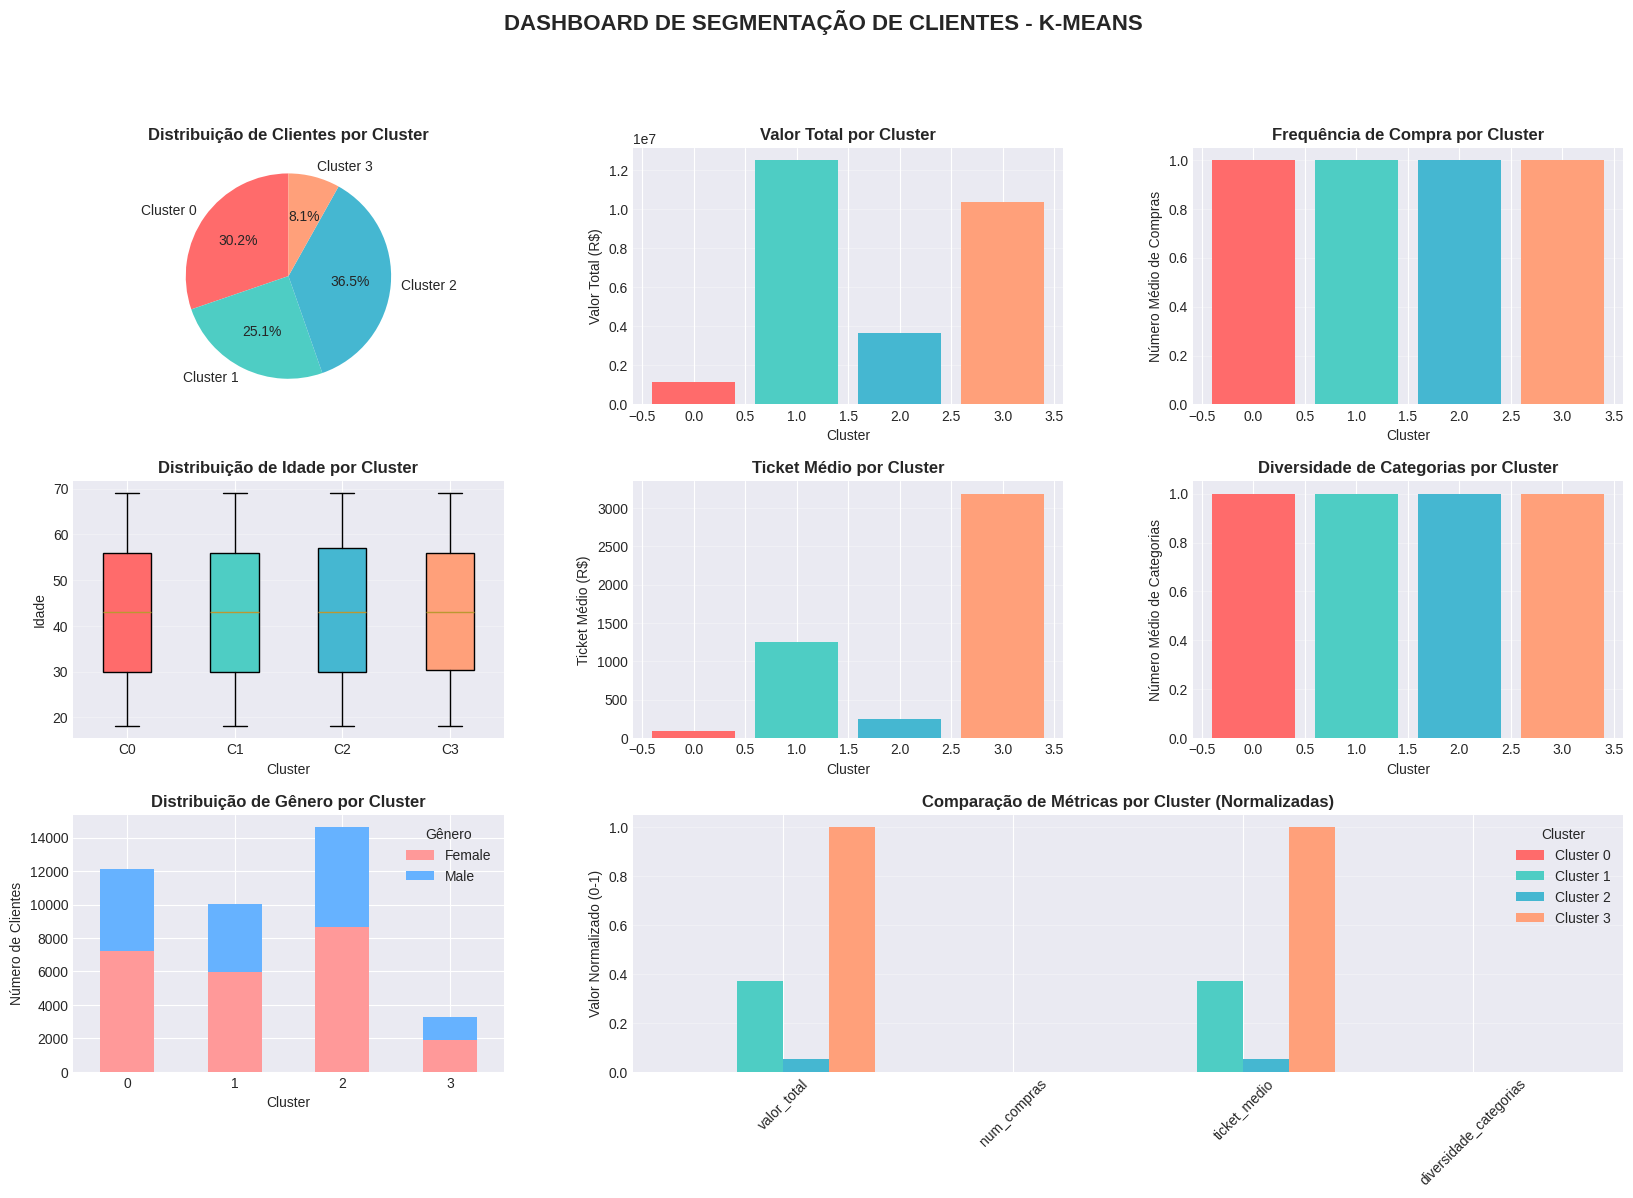


Dashboard gerado com sucesso!

Este dashboard pode ser exportado e apresentado


In [ ]:
# Célula 16 - Dashboard interativo de segmentação

print("="*70)
print("DASHBOARD DE SEGMENTAÇÃO")
print("="*70)

# Criar visualização consolidada
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Distribuição de clusters
ax1 = fig.add_subplot(gs[0, 0])
cluster_counts = customer_features['cluster_kmeans'].value_counts().sort_index()
colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#95E1D3']
ax1.pie(cluster_counts, labels=[f'Cluster {i}' for i in cluster_counts.index],
        autopct='%1.1f%%', colors=colors_palette[:len(cluster_counts)], startangle=90)
ax1.set_title('Distribuição de Clientes por Cluster', fontweight='bold', fontsize=12)

# Valor total por cluster
ax2 = fig.add_subplot(gs[0, 1])
valor_por_cluster = customer_features.groupby('cluster_kmeans')['valor_total'].sum()
ax2.bar(valor_por_cluster.index, valor_por_cluster.values, color=colors_palette[:len(valor_por_cluster)])
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Valor Total (R$)')
ax2.set_title('Valor Total por Cluster', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Número médio de compras por cluster
ax3 = fig.add_subplot(gs[0, 2])
compras_por_cluster = customer_features.groupby('cluster_kmeans')['num_compras'].mean()
ax3.bar(compras_por_cluster.index, compras_por_cluster.values, color=colors_palette[:len(compras_por_cluster)])
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Número Médio de Compras')
ax3.set_title('Frequência de Compra por Cluster', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')

# Distribuição de idade por cluster (boxplot)
ax4 = fig.add_subplot(gs[1, 0])
age_by_cluster = [customer_features[customer_features['cluster_kmeans']==i]['age'].values
                  for i in range(n_clusters)]
bp = ax4.boxplot(age_by_cluster, labels=[f'C{i}' for i in range(n_clusters)], patch_artist=True)
for patch, color in zip(bp['boxes'], colors_palette[:n_clusters]):
    patch.set_facecolor(color)
ax4.set_xlabel('Cluster')
ax4.set_ylabel('Idade')
ax4.set_title('Distribuição de Idade por Cluster', fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3, axis='y')

# Ticket médio por cluster
ax5 = fig.add_subplot(gs[1, 1])
ticket_por_cluster = customer_features.groupby('cluster_kmeans')['ticket_medio'].mean()
ax5.bar(ticket_por_cluster.index, ticket_por_cluster.values, color=colors_palette[:len(ticket_por_cluster)])
ax5.set_xlabel('Cluster')
ax5.set_ylabel('Ticket Médio (R$)')
ax5.set_title('Ticket Médio por Cluster', fontweight='bold', fontsize=12)
ax5.grid(True, alpha=0.3, axis='y')

# Diversidade de categorias por cluster
ax6 = fig.add_subplot(gs[1, 2])
diversidade_por_cluster = customer_features.groupby('cluster_kmeans')['diversidade_categorias'].mean()
ax6.bar(diversidade_por_cluster.index, diversidade_por_cluster.values, color=colors_palette[:len(diversidade_por_cluster)])
ax6.set_xlabel('Cluster')
ax6.set_ylabel('Número Médio de Categorias')
ax6.set_title('Diversidade de Categorias por Cluster', fontweight='bold', fontsize=12)
ax6.grid(True, alpha=0.3, axis='y')

# Distribuição de gênero por cluster
ax7 = fig.add_subplot(gs[2, 0])
gender_cluster = pd.crosstab(customer_features['cluster_kmeans'], customer_features['gender'])
gender_cluster.plot(kind='bar', stacked=True, ax=ax7, color=['#FF9999', '#66B2FF'])
ax7.set_xlabel('Cluster')
ax7.set_ylabel('Número de Clientes')
ax7.set_title('Distribuição de Gênero por Cluster', fontweight='bold', fontsize=12)
ax7.legend(title='Gênero')
ax7.tick_params(axis='x', rotation=0)

# Comparação de métricas normalizadas
ax8 = fig.add_subplot(gs[2, 1:])
metricas_comparacao = customer_features.groupby('cluster_kmeans')[
    ['valor_total', 'num_compras', 'ticket_medio', 'diversidade_categorias']
].mean()
metricas_norm = (metricas_comparacao - metricas_comparacao.min()) / (metricas_comparacao.max() - metricas_comparacao.min())
metricas_norm.T.plot(kind='bar', ax=ax8, width=0.8, color=colors_palette[:n_clusters])
ax8.set_ylabel('Valor Normalizado (0-1)')
ax8.set_title('Comparação de Métricas por Cluster (Normalizadas)', fontweight='bold', fontsize=12)
ax8.legend(title='Cluster', labels=[f'Cluster {i}' for i in range(n_clusters)])
ax8.grid(True, alpha=0.3, axis='y')
ax8.tick_params(axis='x', rotation=45)

plt.suptitle('DASHBOARD DE SEGMENTAÇÃO DE CLIENTES - K-MEANS',
             fontsize=16, fontweight='bold', y=0.995)

plt.show()

print("\nDashboard gerado com sucesso!")
print("\nEste dashboard pode ser exportado e apresentado")

### 💾 17. Conclusões e Exportação do Relatório Final

Na fase final do processamento, consolidamos o dataset com as classificações da Inteligência Artificial (labels) e exportamos a base final em `.csv`. Adicionalmente, geramos um arquivo de texto parametrizado que sumariza as métricas técnicas da execução do modelo, servindo como registro formal do treinamento.

In [ ]:
# Célula 17 - Exportação dos resultados

print("="*70)
print("EXPORTAÇÃO DOS RESULTADOS")
print("="*70)

# Preparar dataset final com todas as informações
df_final = customer_features.copy()

# Adicionar descrição dos clusters
def descrever_cluster(cluster_num):
    """Retorna descrição do cluster"""
    cluster_data = customer_features[customer_features['cluster_kmeans'] == cluster_num]
    valor_total = cluster_data['valor_total'].mean()
    num_compras = cluster_data['num_compras'].mean()

    if valor_total > customer_features['valor_total'].quantile(0.75) and num_compras > customer_features['num_compras'].quantile(0.75):
        return "VIP - Alto Valor & Alta Frequência"
    elif valor_total > customer_features['valor_total'].quantile(0.5) and num_compras > customer_features['num_compras'].quantile(0.5):
        return "Fiéis - Clientes Regulares"
    elif num_compras < customer_features['num_compras'].quantile(0.25):
        return "Ocasionais - Potencial de Crescimento"
    else:
        return "Padrão - Comportamento Médio"

df_final['cluster_descricao'] = df_final['cluster_kmeans'].apply(descrever_cluster)

# Salvar em CSV
output_path = '/content/dataset/clientes_segmentados.csv'
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\nArquivo CSV salvo em: {output_path}")

# Criar relatório resumido
relatorio_path = '/content/dataset/relatorio_segmentacao.txt'
with open(relatorio_path, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("RELATÓRIO DE SEGMENTAÇÃO DE CLIENTES\n")
    f.write("="*70 + "\n\n")

    f.write(f"Data da análise: {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}\n")
    f.write(f"Total de clientes analisados: {len(customer_features)}\n")
    f.write(f"Algoritmo utilizado: K-Means\n")
    f.write(f"Número de clusters: {n_clusters}\n\n")

    f.write("MÉTRICAS DE DESEMPENHO:\n")
    f.write(f"- Silhouette Score: {silhouette_kmeans:.4f}\n")
    f.write(f"- Davies-Bouldin Index: {davies_bouldin_kmeans:.4f}\n")
    f.write(f"- Calinski-Harabasz Index: {calinski_harabasz_kmeans:.2f}\n\n")

    f.write("DISTRIBUIÇÃO DOS CLUSTERS:\n")
    for cluster in range(n_clusters):
        cluster_data = customer_features[customer_features['cluster_kmeans'] == cluster]
        desc = descrever_cluster(cluster)
        f.write(f"\nCluster {cluster} - {desc}:\n")
        f.write(f"  - Tamanho: {len(cluster_data)} clientes ({len(cluster_data)/len(customer_features)*100:.1f}%)\n")
        f.write(f"  - Valor total médio: R$ {cluster_data['valor_total'].mean():.2f}\n")
        f.write(f"  - Número médio de compras: {cluster_data['num_compras'].mean():.1f}\n")
        f.write(f"  - Ticket médio: R$ {cluster_data['ticket_medio'].mean():.2f}\n")
        f.write(f"  - Idade média: {cluster_data['age'].mean():.1f} anos\n")

print(f"Relatório de texto salvo em: {relatorio_path}")

# Exibir preview
print(f"\nPREVIEW DOS DADOS EXPORTADOS:")
print(df_final[['customer_id', 'age', 'gender', 'valor_total', 'num_compras',
                'cluster_kmeans', 'cluster_descricao']].head(10))

print(f"\nEXPORTAÇÃO CONCLUÍDA COM SUCESSO!")
print(f"\nArquivos gerados:")
print(f"   1. {output_path}")
print(f"   2. {relatorio_path}")

EXPORTAÇÃO DOS RESULTADOS

Arquivo CSV salvo em: /content/dataset/clientes_segmentados.csv
Relatório de texto salvo em: /content/dataset/relatorio_segmentacao.txt

PREVIEW DOS DADOS EXPORTADOS:
  customer_id  age  gender  valor_total  num_compras  cluster_kmeans  \
0     C100004   61    Male      1500.40            1               1   
1     C100005   34    Male      1200.34            1               1   
2     C100012   25    Male        26.15            1               0   
3     C100025   55    Male        71.68            1               2   
4     C100028   21  Female        15.15            1               2   
5     C100034   60    Male       600.16            1               2   
6     C100041   50  Female       900.24            1               1   
7     C100042   28  Female       162.64            1               0   
8     C100113   48  Female      1200.32            1               1   
9     C100130   42  Female      1800.51            1               1   

             